In [2]:
import pandas as pd
import numpy as np
from sklearn import linear_model
import matplotlib.pyplot as plt

In [9]:
df = pd.read_csv("C:/Users/redmi/Downloads/homeprices.csv")
df


,area,price
0,2600,550000
1,3000,565000
2,3200,610000
3,3600,680000
4,4000,725000


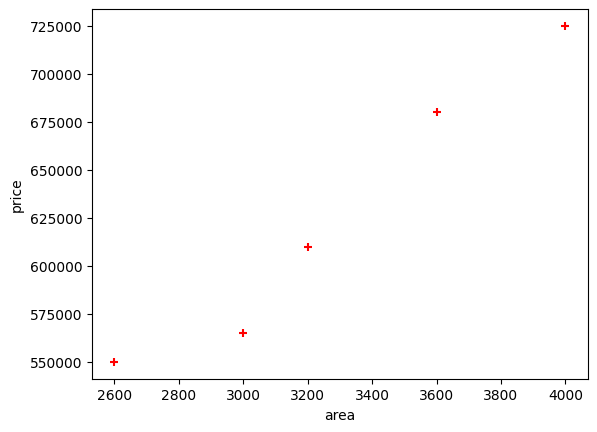

In [10]:

plt.xlabel('area')
plt.ylabel('price')
plt.scatter(df.area,df.price,color='red',marker='+')

In [11]:
area=df.drop('price',axis='columns')
area

,area
0,2600
1,3000
2,3200
3,3600
4,4000


In [12]:
price=df.price
price

0    550000
1    565000
2    610000
3    680000
4    725000
Name: price, dtype: int64

In [14]:
#equation for Linear reg y=mx+c

reg=linear_model.LinearRegression()
reg.fit(area,price)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
reg.coef_

array([135.78767123])

In [16]:
reg.intercept_

np.float64(180616.43835616432)

In [23]:
#to predict the new area 3500 

new_data = pd.DataFrame([[3500]], columns=['area'])
prediction = reg.predict(new_data)
prediction=np.round(prediction,2)
prediction

array([655873.29])

In [24]:
135.78767123*3500+180616.43835616432

655873.2876611643

In [26]:
p=reg.predict(df[['area']])
p=np.round(p,2)
p


array([533664.38, 587979.45, 615136.99, 669452.05, 723767.12])

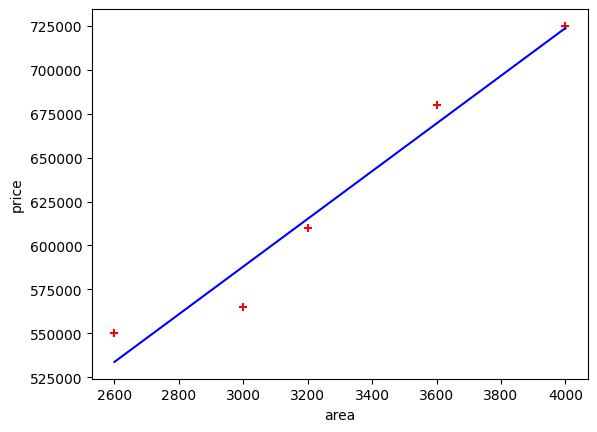

In [28]:
plt.xlabel('area')
plt.ylabel('price')
plt.scatter(df.area,df.price,color='red',marker='+')
plt.plot(df.area,reg.predict(df[['area']]),color='blue')

In [29]:
reg.score(df[['area']],df.price)

0.9584301138199486

In [32]:
#give me prediction for area=6500 and 10000

import pandas as pd

new_data = pd.DataFrame({
    'area': [6500, 10000]
})

predicted_prices = reg.predict(new_data)

predicted_prices

array([1063236.30136986, 1538493.15068493])

In [40]:
d = pd.read_csv("C:/Users/redmi/Downloads/areas.csv")
d.head()

,area
0,1000
1,1500
2,2300
3,3540
4,4120


In [41]:
pred=reg.predict(d)
pred=np.round(pred,2)
pred

array([ 316404.11,  384297.95,  492928.08,  661304.79,  740061.64,
        799808.22,  926090.75,  650441.78,  825607.88,  492928.08,
       1402705.48, 1348390.41, 1144708.9 ])

In [43]:
d['predicted_price']=pred

In [44]:
d

,area,predicted_price
0,1000,316404.11
1,1500,384297.95
2,2300,492928.08
3,3540,661304.79
4,4120,740061.64
5,4560,799808.22
6,5490,926090.75
7,3460,650441.78
8,4750,825607.88
9,2300,492928.08


In [45]:
d.to_csv("Downloads/predicted_price.csv",index=False)

In [46]:
reg.score(d[['area']],d.predicted_price)

0.9999999999999999